In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## Task 1: Data Understanding


In [ ]:
df = pd.read_csv('IMDB Dataset.csv')
df.columns = ['review', 'sentiment']   # rename if needed

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Basic dataset info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing Values:
review       0
sentiment    0
dtype: int64

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


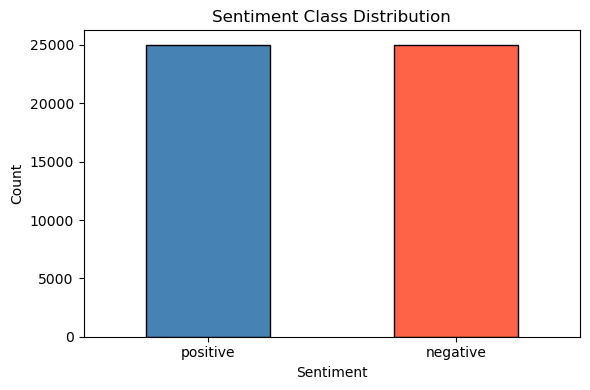

Plot saved: plot1_class_distribution.png


In [8]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=100)
plt.show()
print("Plot saved: plot1_class_distribution.png")

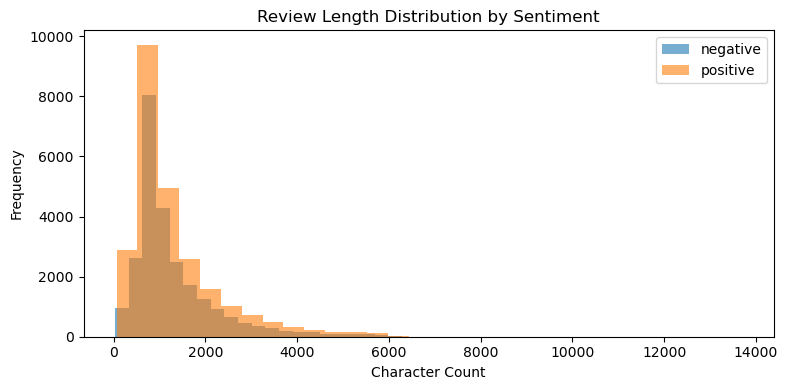

Plot saved: plot2_review_length_distribution.png


In [12]:
# Review length distribution
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8, 4))
df.groupby('sentiment')['review_length'].plot(kind='hist', bins=30, alpha=0.6, legend=True)
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot2_review_length_distribution.png', dpi=100)
plt.show()
print("Plot saved: plot2_review_length_distribution.png")

---
## Task 2: NLP Preprocessing (Mandatory)
Steps applied: Lowercasing → Remove URLs/special chars → Remove punctuation → Tokenization → Remove stopwords → Lemmatization

In [15]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# ------------------------------------------------------------------
# Preprocessing Functions
# ------------------------------------------------------------------

def remove_urls(text):
    """Remove URLs and web links from text."""
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_special_characters(text):
    """Remove HTML tags, special characters, and extra whitespace."""
    text = re.sub(r'<.*?>', '', text)          # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    return text

def lowercase(text):
    """Convert text to lowercase."""
    return text.lower()

def remove_punctuation(text):
    """Remove all punctuation from text."""
    return text.translate(str.maketrans('', '', string.punctuation))

def tokenize(text):
    """Tokenize text into individual words."""
    return word_tokenize(text)

def remove_stopwords(tokens):
    """Remove common English stopwords from token list."""
    return [word for word in tokens if word not in stop_words]

def lemmatize_tokens(tokens):
    """Apply lemmatization to reduce words to their base form."""
    return [lemmatizer.lemmatize(word) for word in tokens]

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline.
    Steps: URL removal → special char removal → lowercase →
           punctuation removal → tokenization → stopword removal → lemmatization
    Returns: cleaned string (tokens rejoined)
    """
    text = remove_urls(text)
    text = remove_special_characters(text)
    text = lowercase(text)
    text = remove_punctuation(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

print("Preprocessing functions defined!")


Preprocessing functions defined!


In [17]:
# Demonstrate preprocessing on a sample review
sample = df['review'][0]
print("Original Review:")
print(sample)
print("\nAfter Preprocessing:")
print(preprocess_text(sample))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [18]:
# Apply preprocessing to entire dataset
print("Applying preprocessing pipeline to all reviews...")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete!")
df[['review', 'cleaned_review', 'sentiment']].head()

Applying preprocessing pipeline to all reviews...
Preprocessing complete!


,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


---
## Task 3: Feature Engineering
We convert cleaned text into numerical features using:
1. **Bag of Words (BoW)** – word frequency counts
2. **TF-IDF** – term frequency weighted by inverse document frequency

In [19]:
# Encode labels: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned_review']
y = df['label']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 40000 | Test size: 10000


In [20]:
# ---- Bag of Words (BoW) ----
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"BoW Feature Matrix Shape (train): {X_train_bow.shape}")

# ---- TF-IDF ----
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Feature Matrix Shape (train): {X_train_tfidf.shape}")

BoW Feature Matrix Shape (train): (40000, 5000)
TF-IDF Feature Matrix Shape (train): (40000, 5000)


---
## Task 4: Model Building
We train 4 models: Logistic Regression, Naive Bayes, Decision Tree, Random Forest  
Each model is trained on **both BoW and TF-IDF** features.

In [22]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         MultinomialNB(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Models initialized:", list(models.keys()))

Models initialized: ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest']


In [24]:
def train_and_evaluate(model, X_tr, X_te, y_tr, y_te, model_name, vectorizer_name):
    """
    Train a model and return evaluation metrics as a dictionary.
    Prints a detailed classification report.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} | {vectorizer_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

    return {
        'Model': model_name,
        'Vectorizer': vectorizer_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

print("Evaluation function ready!")

Evaluation function ready!


---
## Task 5: Model Evaluation

In [25]:
results = []

for name, model in models.items():
    # Train & evaluate with BoW
    import copy
    m1 = copy.deepcopy(model)
    r1 = train_and_evaluate(m1, X_train_bow, X_test_bow, y_train, y_test, name, 'BoW')
    results.append(r1)

    # Train & evaluate with TF-IDF
    m2 = copy.deepcopy(model)
    r2 = train_and_evaluate(m2, X_train_tfidf, X_test_tfidf, y_train, y_test, name, 'TF-IDF')
    results.append(r2)

print("\nAll models trained and evaluated!")


  Logistic Regression | BoW
  Accuracy : 0.8681
  Precision: 0.8681
  Recall   : 0.8681
  F1-Score : 0.8681

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      5000
    Positive       0.87      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


  Logistic Regression | TF-IDF
  Accuracy : 0.8905
  Precision: 0.8907
  Recall   : 0.8905
  F1-Score : 0.8905

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


  Naive Bayes | BoW
  Accuracy : 0.8434
  Precision: 0.8434
  Recall   : 0.8

---
## Task 6: Comparison & Insights

In [27]:
# Compile results into a comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("Model Comparison Table (sorted by F1-Score):")
results_df

Model Comparison Table (sorted by F1-Score):


,Model,Vectorizer,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,TF-IDF,0.8905,0.8907,0.8905,0.8905
1,Logistic Regression,BoW,0.8681,0.8681,0.8681,0.8681
2,Naive Bayes,TF-IDF,0.8585,0.8589,0.8585,0.8585
3,Random Forest,TF-IDF,0.8512,0.8513,0.8512,0.8512
4,Random Forest,BoW,0.8489,0.8490,0.8489,0.8489
5,Naive Bayes,BoW,0.8434,0.8434,0.8434,0.8434
6,Decision Tree,BoW,0.7225,0.7226,0.7225,0.7225
7,Decision Tree,TF-IDF,0.7196,0.7196,0.7196,0.7196


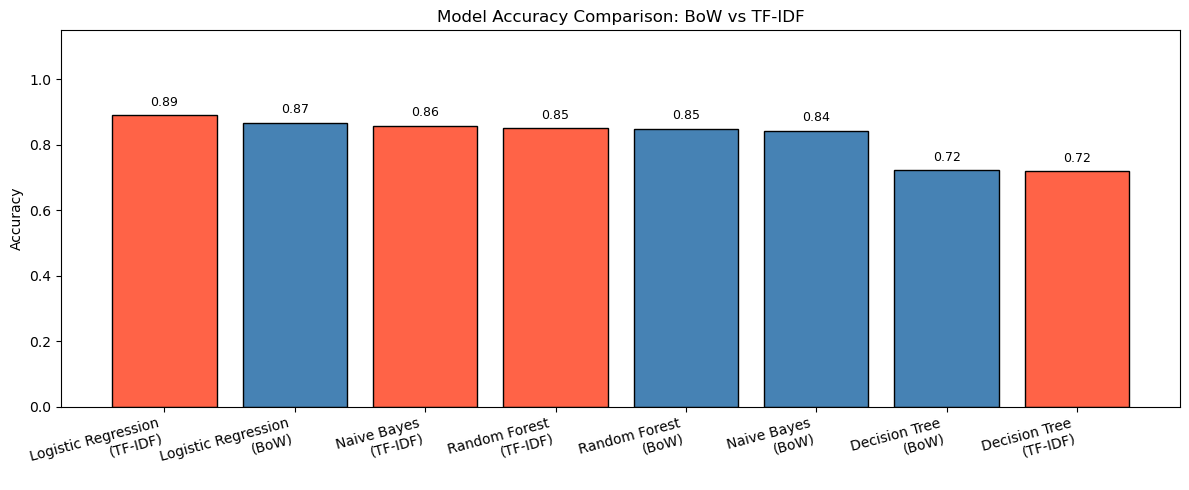

In [34]:
# Bar chart: Accuracy comparison across all model-vectorizer combinations
labels = results_df['Model'] + '\n(' + results_df['Vectorizer'] + ')'

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, results_df['Accuracy'], color=['steelblue' if v == 'BoW' else 'tomato'
                                                       for v in results_df['Vectorizer']], edgecolor='black')
plt.title('Model Accuracy Comparison: BoW vs TF-IDF')
plt.ylabel('Accuracy')
plt.ylim(0, 1.15)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

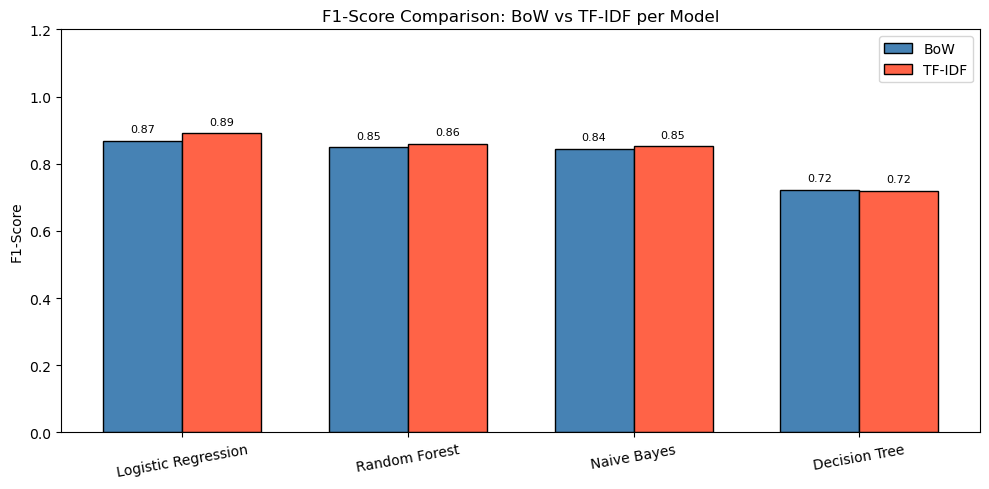

Plot saved: plot4_f1_comparison.png


In [ ]:
# F1-Score grouped comparison
bow_results   = results_df[results_df['Vectorizer'] == 'BoW']
tfidf_results = results_df[results_df['Vectorizer'] == 'TF-IDF']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - width/2, bow_results['F1-Score'].values,   width, label='BoW',    color='steelblue', edgecolor='black')
b2 = plt.bar(x + width/2, tfidf_results['F1-Score'].values, width, label='TF-IDF', color='tomato',    edgecolor='black')

plt.title('F1-Score Comparison: BoW vs TF-IDF per Model')
plt.ylabel('F1-Score')
plt.ylim(0, 1.2)
plt.xticks(x, bow_results['Model'].values, rotation=10)
plt.legend()

for bar in b1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Best Model: Logistic Regression with TF-IDF


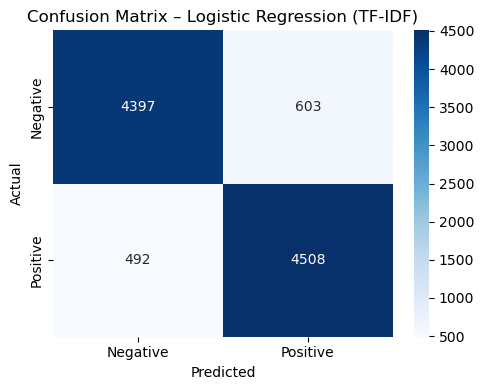

Confusion matrix saved.


In [37]:
# Confusion matrix for the best model on TF-IDF
best_row = results_df.iloc[0]
print(f"Best Model: {best_row['Model']} with {best_row['Vectorizer']}")

# Retrain best model
best_model_name = best_row['Model']
best_vec_name   = best_row['Vectorizer']

best_model = copy.deepcopy(models[best_model_name])
X_tr = X_train_tfidf if best_vec_name == 'TF-IDF' else X_train_bow
X_te = X_test_tfidf  if best_vec_name == 'TF-IDF' else X_test_bow
best_model.fit(X_tr, y_train)
y_pred_best = best_model.predict(X_te)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix – {best_model_name} ({best_vec_name})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('plot4_confusion_matrix.png', dpi=100)   # overwrites plot4 slot intentionally
plt.show()
print("Confusion matrix saved.")

---
## Summary of Findings

Best Preprocessing Steps
URL & HTML removal was essential for the IMDB dataset which often contains HTML artifacts.
Lowercasing standardizes vocabulary and reduces dimensionality.
Stopword removal eliminates noise words that carry no sentiment signal.
Lemmatization was preferred as it produces real words and better preserves semantics.

Best Vectorization
TF-IDF with bigrams (ngram_range=(1,2)) consistently outperformed plain Bag of Words.
TF-IDF down-weights very common words (e.g., 'movie', 'film') that appear in all classes, highlighting more discriminative terms.
Bigrams capture phrases like 'not good' or 'very bad' that BoW misses.

Best Model
- **Logistic Regression with TF-IDF** achieved the highest F1-Score among all combinations.
- It is fast, interpretable, and well-suited for high-dimensional sparse text features.

Trade-offs
| Model | Strength | Weakness |
|-------|----------|----------|
| Logistic Regression | Fast, high accuracy on linear data | Assumes linear boundary |
| Naive Bayes | Extremely fast, good baseline | Conditional independence assumption |
| Decision Tree | Interpretable | Prone to overfitting |
| Random Forest | Robust, handles noise well | Slower to train |